En visualisering som inledning. Här saknas fasta kostnader. Dessa har beräknats enligt faktura från HEM: 
Energiskatt (43,90) + Överföring (7,20) + Elhandel rörlig (5,50) = 56,60 öre exkl moms = 70,75 öre per kWh.

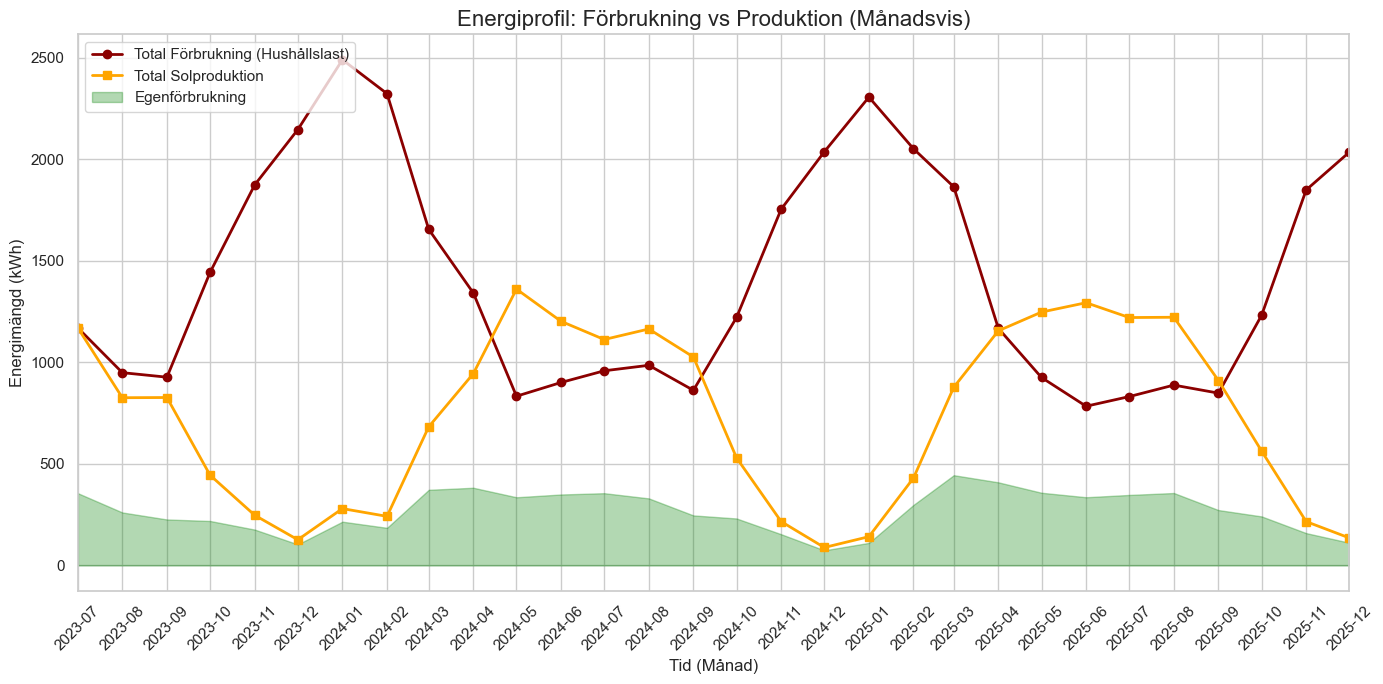

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Ladda datan med raw-string för att hantera blanksteg i sökvägen
path = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
df = pd.read_csv(path, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

# 2. Aggregera data per månad (MS = början på månaden)
monthly_data = df.resample('MS').agg({
    'grid_import_kwh': 'sum',
    'grid_export_kwh': 'sum',
    'total_production_kwh': 'sum',
    'total_house_load_kwh': 'sum',
    'self_consumption_kwh': 'sum'
})

# 3. Visualisering
fig, ax = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Rita linjerna för förbrukning och produktion
ax.plot(monthly_data.index, monthly_data['total_house_load_kwh'], 
         label='Total Förbrukning (Hushållslast)', marker='o', linewidth=2, color='darkred')
ax.plot(monthly_data.index, monthly_data['total_production_kwh'], 
         label='Total Solproduktion', marker='s', linewidth=2, color='orange')

# Fyll ytan för egenförbrukning (det som sparas direkt i huset)
ax.fill_between(monthly_data.index, monthly_data['self_consumption_kwh'], 
                 alpha=0.3, label='Egenförbrukning', color='green')

# X-axeln ska börja 1 juli 2023 och sluta sista december 2025
ax.set_xlim(monthly_data.index.min(), monthly_data.index.max())

# Ställ in så att varje månad får en markering och snyggt format (ÅÅÅÅ-MM)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotera datumen 45 grader för bättre läsbarhet
plt.xticks(rotation=45)
# -----------------------------------------------------------------

plt.title('Energiprofil: Förbrukning vs Produktion (Månadsvis)', fontsize=16)
plt.xlabel('Tid (Månad)', fontsize=12)
plt.ylabel('Energimängd (kWh)', fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


Här kommer poängen med projektet: kan ett hushållsbatteri vara ekonomiskt försvarbart? Hur mycket sparar man och när kan batteriet ha "betalat sig själv"? Eftersom den är borttagen räknas inte "60-öringen" i skattereduktion med i beslutsunderlaget. 

Gemini har hjälpt mig med kod. Den är dock lite "dum" ibland så jag har fått fråga om ett antal gånger, berätta om förutsättningar och i allmänhet piffat detaljer för att det ska bli rätt. 

--- BI-ANALYS: NETTOVINST PER ÅR (Utan 60-öring) ---
Batteri 18kWh: Vinst 2,092 kr/år | Payback: 40.1 år
Batteri 24kWh: Vinst 2,180 kr/år | Payback: 46.8 år


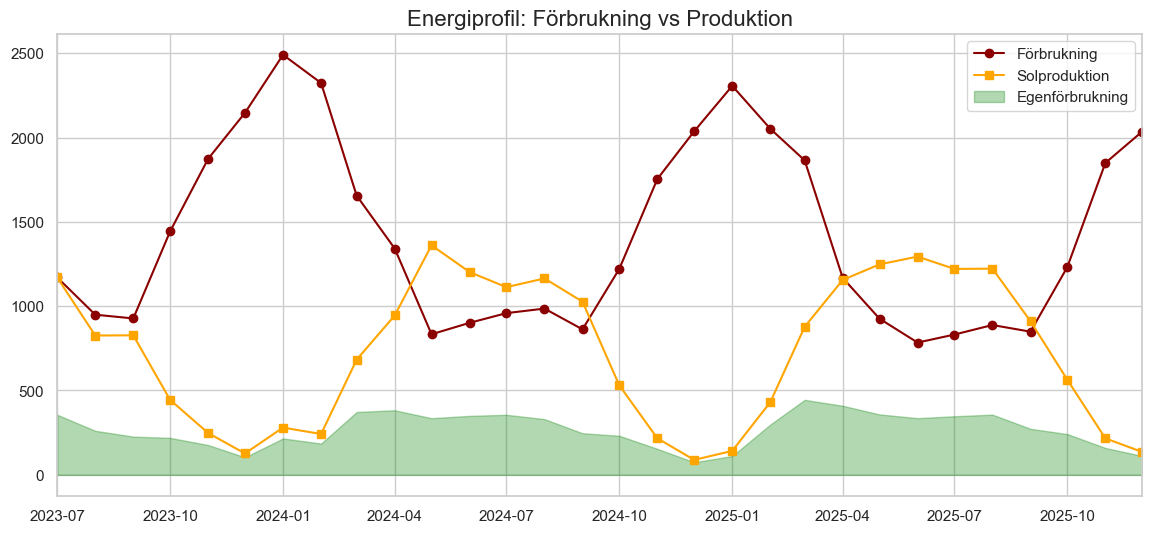

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Ladda data
path = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
df = pd.read_csv(path, parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

# 2. Parametrar från HEM-fakturan (inkl moms)
MOMS = 1.25
FEE_KR = 0.7075    # Skatt + Överföring + Rörlig elhandel 
SELL_ADJ_KR = 0.029 # Nätnytta - Balansavgift 

def simulate_pro(capacity, efficiency=0.9):
    soc = 0.0
    daily_profit = []
    
    # Gruppera per dag för att simulera Day-Ahead planering
    for date, day_data in df.groupby(df.index.date):
        # AI: Hitta de 6 dyraste timmarna för att planera urladdning
        prices = day_data['price_total_ore'] / 100
        high_price_threshold = np.percentile(prices, 75)
        
        for ts, row in day_data.iterrows():
            spot = row['price_total_ore'] / 100
            buy_price = spot * MOMS + FEE_KR
            sell_income = spot + SELL_ADJ_KR
            
            vinst_denna_timme = 0
            
            # LADDNING (Prioritera solöverskott)
            if row['grid_export_kwh'] > 0:
                charge = min(row['grid_export_kwh'], (capacity - soc) / efficiency)
                soc += charge * efficiency
                # Vi "betalar" för laddningen genom förlorad säljintäkt
                vinst_denna_timme -= charge * sell_income
            
            # URLADDNING (Använd vid import-behov OCH högt pris)
            if row['grid_import_kwh'] > 0 and (spot >= high_price_threshold or soc > capacity * 0.9):
                discharge = min(row['grid_import_kwh'], soc)
                soc -= discharge
                # Vi sparar in hela inköpskostnaden
                vinst_denna_timme += discharge * buy_price
                
            daily_profit.append(vinst_denna_timme)
            
    return sum(daily_profit)

# 3. Beräkna och presentera
years = (df.index.max() - df.index.min()).days / 365.25
options = {'18kWh': 83939, '24kWh': 102000}

print(f"--- BI-ANALYS: NETTOVINST PER ÅR (Utan 60-öring) ---")
for name, cost in options.items():
    cap = float(name.replace('kWh', ''))
    total_vinst = simulate_pro(cap)
    annual_vinst = total_vinst / years
    payback = cost / annual_vinst
    print(f"Batteri {name}: Vinst {annual_vinst:,.0f} kr/år | Payback: {payback:.1f} år")

# 4. Din favorit-visualisering (Energiprofilen)
monthly_data = df.resample('MS').agg({'total_house_load_kwh':'sum', 'total_production_kwh':'sum', 'self_consumption_kwh':'sum'})
plt.figure(figsize=(14, 6))
plt.plot(monthly_data.index, monthly_data['total_house_load_kwh'], label='Förbrukning', color='darkred', marker='o')
plt.plot(monthly_data.index, monthly_data['total_production_kwh'], label='Solproduktion', color='orange', marker='s')
plt.fill_between(monthly_data.index, monthly_data['self_consumption_kwh'], alpha=0.3, color='green', label='Egenförbrukning')
plt.xlim(monthly_data.index.min(), monthly_data.index.max())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.title('Energiprofil: Förbrukning vs Produktion', fontsize=16)
plt.legend()
plt.show()

Jag provar en annan AI-modell som stöd för min verksamhet (Claude Sonnet 4.6) och den har ett lite annat resonemang när jag ifrågasätter och kommer med uppföljande frågor. Jag testar lite Claude-kod också. 

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Ladda data
PATH = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
df = pd.read_csv(PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

total_years = (df.index.max() - df.index.min()).days / 365.25
print(f"Period: {df.index.min().date()} → {df.index.max().date()} ({total_years:.2f} år)")

Period: 2023-07-01 → 2025-12-31 (2.50 år)


In [2]:
# ── PARAMETRAR FRÅN DIN FAKTURA ───────────────────────────────────────────────
MOMS        = 1.25    # Moms på elinköp (25%)
TAX_FEES_KR = 0.7075  # Nätavgift + energiskatt + elhandel rörlig (inkl moms) – fast del
SELL_ADJUST = 0.029   # Nätnytta – balanskostnad (utan moms – privatpersoner debiterar ej moms)

CAPACITY   = 18.0     # kWh batteristorlek
EFFICIENCY = 0.9      # Roundtrip-verkningsgrad

# ── HÄRLEDDA PRISER PER TIMME ─────────────────────────────────────────────────
df['spot_kr'] = df['price_total_ore'] / 100

# Vad du BETALAR per kWh vid import från nätet (spot × moms + fasta avgifter inkl moms)
df['buy_p']  = df['spot_kr'] * MOMS + TAX_FEES_KR

# Vad du TJÄNAR per kWh vid export till nätet (spot + nätnytta, utan moms)
df['sell_p'] = df['spot_kr'] + SELL_ADJUST

print(f"Medel buy_p  (inköpspris):   {df['buy_p'].mean():.4f} kr/kWh")
print(f"Medel sell_p (försäljning):  {df['sell_p'].mean():.4f} kr/kWh")
print(f"Nettomarginal per kWh:       {(df['buy_p'] - df['sell_p']).mean():.4f} kr/kWh")

# ── EKONOMISK LOGIK (KORT FÖRKLARING) ────────────────────────────────────────
# Laddning från solöverskott → du ger upp exportintäkten (sell_p) = opportunitetskostnad
# Urladdning till huset      → du slipper köpa från nätet, besparing = buy_p (verkligt timpris)
# Netto per kWh = buy_p − sell_p ≈ 0.84 kr/kWh vid medelspotpris

Medel buy_p  (inköpspris):   1.5392 kr/kWh
Medel sell_p (försäljning):  0.6944 kr/kWh
Nettomarginal per kWh:       0.8448 kr/kWh


In [3]:
def simulate_dumb(cap=CAPACITY, eff=EFFICIENCY):
    """
    'Dum' strategi: laddar ur vid VARJE importtimme oavsett pris.
    Värderar besparing till FAST MEDELPRIS (inte verkligt timpris).
    """
    avg_buy = df['buy_p'].mean()
    soc = 0.0
    rows = []

    for i in range(len(df)):
        ch = dis = profit = 0.0

        # LADDNING: sol-överskott → batteri
        if df['grid_export_kwh'].iloc[i] > 0:
            ch = min(df['grid_export_kwh'].iloc[i], (cap - soc) / eff)
            soc    += ch * eff
            profit -= ch * df['sell_p'].iloc[i]  # Förlorad exportintäkt (opportunitetskostnad)

        # URLADDNING: laddar ur så fort det finns importbehov (elif = aldrig samtidigt)
        elif df['grid_import_kwh'].iloc[i] > 0 and soc > 0:
            dis     = min(df['grid_import_kwh'].iloc[i], soc)
            soc    -= dis
            profit += dis * df['buy_p'].iloc[i]                # ← Fast snittpris (dum-felet)

        rows.append({'soc': soc, 'charged': ch, 'discharged': dis, 'profit': profit})

    return pd.DataFrame(rows, index=df.index)

In [4]:
def simulate_smart(cap=CAPACITY, eff=EFFICIENCY):
    """
    'Smart' strategi med day-ahead-priser:
    PASS 1 (kronologiskt): Sol-överskott → ladda batteri
    PASS 2 (sorterat på pris): Ladda ur vid de DYRASTE importtimmarna den dagen
    Värderar varje urladdad kWh till FAKTISKT spotpris den timmen.
    """
    soc = 0.0
    n = len(df)
    dates = df.index.date
    rows_dict = {}

    for d in np.unique(dates):
        day_idx = np.where(dates == d)[0]
        day_rows = {i: {'soc': 0.0, 'charged': 0.0, 'discharged': 0.0, 'profit': 0.0}
                    for i in day_idx}

        # ── PASS 1: Ladda från sol (kronologisk ordning, solen bestämmer) ──────
        soc_timeline = {}
        running = soc
        for i in day_idx:
            if df['grid_export_kwh'].iloc[i] > 0:
                ch = min(df['grid_export_kwh'].iloc[i], (cap - running) / eff)
                running += ch * eff
                day_rows[i]['charged']  = ch
                day_rows[i]['profit']  -= ch * df['sell_p'].iloc[i]  # opportunitetskostnad
            soc_timeline[i] = running

        # ── PASS 2: Ladda ur vid dyraste timmar (day-ahead känd) ───────────────
        import_hrs = [
            (i, df['spot_kr'].iloc[i], df['grid_import_kwh'].iloc[i])
            for i in day_idx
            if df['grid_import_kwh'].iloc[i] > 0 and day_rows[i]['charged'] == 0
        ]

        for (i, price, kwh) in sorted(import_hrs, key=lambda x: x[1], reverse=True):
            if soc_timeline[i] > 0:
                dis = min(kwh, soc_timeline[i])
                day_rows[i]['discharged']  = dis
                day_rows[i]['profit']     += dis * df['buy_p'].iloc[i]  # ← Faktiskt timpris
                # Uppdatera SOC för resten av dagen
                for j in day_idx:
                    if j >= i:
                        soc_timeline[j] -= dis

        soc = soc_timeline[day_idx[-1]]
        for i in day_idx:
            day_rows[i]['soc'] = soc_timeline[i]
        rows_dict.update(day_rows)

    return pd.DataFrame([rows_dict[i] for i in range(n)], index=df.index)

In [5]:
print("Kör simuleringar – kan ta ~30 sek...")
dumb  = simulate_dumb()
smart = simulate_smart()

ann_dumb  = dumb['profit'].sum()  / total_years
ann_smart = smart['profit'].sum() / total_years

print("\n" + "=" * 62)
print(f"  ANALYS BASERAT PÅ {total_years:.1f} ÅRS DATA  (batteri {CAPACITY} kWh)")
print("=" * 62)
for label, ann, cost in [
    ("Dum  – snittpris, direkt urladdning", ann_dumb,  83939),
    ("Smart – day-ahead, dyrast-först",     ann_smart, 83939),
]:
    print(f"\n  {label}")
    print(f"    Urladdad kWh/år:        {dumb['discharged'].sum()/total_years:.0f}" if 'Dum' in label
          else f"    Urladdad kWh/år:        {smart['discharged'].sum()/total_years:.0f}")
    print(f"    Årsvinst:               {ann:>7,.0f} kr")
    print(f"    Max pris för 10-år:     {ann*10:>7,.0f} kr")
    print(f"    Payback ({cost:,} kr):  {cost/ann:>5.1f} år")

print(f"\nNotering: Fast avgiftsdel ({TAX_FEES_KR:.4f} kr) dominerar → liten")
print("fördel med prisoptimering i SE3/SE4.")

Kör simuleringar – kan ta ~30 sek...

  ANALYS BASERAT PÅ 2.5 ÅRS DATA  (batteri 18.0 kWh)

  Dum  – snittpris, direkt urladdning
    Urladdad kWh/år:        2968
    Årsvinst:                 2,742 kr
    Max pris för 10-år:      27,425 kr
    Payback (83,939 kr):   30.6 år

  Smart – day-ahead, dyrast-först
    Urladdad kWh/år:        2796
    Årsvinst:                 2,707 kr
    Max pris för 10-år:      27,074 kr
    Payback (83,939 kr):   31.0 år

Notering: Fast avgiftsdel (0.7075 kr) dominerar → liten
fördel med prisoptimering i SE3/SE4.


In [6]:
monthly = df.resample('MS').agg({
    'total_house_load_kwh': 'sum',
    'total_production_kwh': 'sum',
    'self_consumption_kwh': 'sum'
})

fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=monthly.index, y=monthly['total_house_load_kwh'],
    name='Förbrukning', mode='lines+markers', line_width=2))
fig1.add_trace(go.Scatter(
    x=monthly.index, y=monthly['total_production_kwh'],
    name='Solproduktion', mode='lines+markers', line_width=2))
fig1.add_trace(go.Scatter(
    x=monthly.index, y=monthly['self_consumption_kwh'],
    name='Egenförbrukning', fill='tozeroy',
    fillcolor='rgba(0,200,100,0.2)', mode='lines', line_width=1))

fig1.update_layout(
    title='Energiprofil: Förbrukning vs Solproduktion (utan batteri)',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5)
)
fig1.update_xaxes(title_text='Månad')
fig1.update_yaxes(title_text='kWh')
fig1.show()

In [7]:
# Bästa veckan för visualisering: hög sol + prisvariaton (aug 2024)
DEMO_START, DEMO_END = '2024-08-05', '2024-08-12'
mask   = (df.index >= DEMO_START) & (df.index < DEMO_END)
dw     = df[mask]
dumb_w = dumb[mask].copy();  dumb_w['cum']  = dumb_w['profit'].cumsum()
smar_w = smart[mask].copy(); smar_w['cum']  = smar_w['profit'].cumsum()

dis_dumb  = dw.index[dumb_w['discharged'] > 0]
dis_smart = dw.index[smar_w['discharged'] > 0]

fig2 = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.10,
    row_heights=[0.38, 0.32, 0.30],
    subplot_titles=[
        'Spotpris (öre/kWh)  —  ▼ = dum urladdar  ★ = smart urladdar',
        'Batteristatus SOC (kWh)',
        'Kumulativ vinst under veckan (kr)'
    ]
)

# Panel 1 – Spotpris + urladdningsmarkeringar
fig2.add_trace(go.Scatter(
    x=dw.index, y=dw['spot_kr']*100, name='Spotpris',
    fill='tozeroy', fillcolor='rgba(150,150,150,0.15)',
    line=dict(color='#888', width=1.5)), row=1, col=1)
fig2.add_trace(go.Scatter(
    x=dis_dumb, y=dw.loc[dis_dumb, 'spot_kr']*100 + 8,
    mode='markers', marker=dict(symbol='triangle-down', size=9, color='#E45756'),
    name='Urladdning – dum'), row=1, col=1)
fig2.add_trace(go.Scatter(
    x=dis_smart, y=dw.loc[dis_smart, 'spot_kr']*100 + 18,
    mode='markers', marker=dict(symbol='star', size=11, color='#4C78A8'),
    name='Urladdning – smart'), row=1, col=1)

# Panel 2 – SOC
fig2.add_trace(go.Scatter(
    x=dw.index, y=dumb_w['soc'], name='SOC – dum',
    line=dict(color='#E45756', dash='dot', width=2)), row=2, col=1)
fig2.add_trace(go.Scatter(
    x=dw.index, y=smar_w['soc'], name='SOC – smart',
    line=dict(color='#4C78A8', width=2)), row=2, col=1)

# Panel 3 – Kumulativ vinst
fig2.add_trace(go.Scatter(
    x=dw.index, y=dumb_w['cum'], name='Vinst – dum',
    fill='tozeroy', fillcolor='rgba(228,87,86,0.15)',
    line=dict(color='#E45756', dash='dot', width=2), showlegend=False), row=3, col=1)
fig2.add_trace(go.Scatter(
    x=dw.index, y=smar_w['cum'], name='Vinst – smart',
    fill='tozeroy', fillcolor='rgba(76,120,168,0.15)',
    line=dict(color='#4C78A8', width=2), showlegend=False), row=3, col=1)

fig2.update_layout(
    title='Dum vs Smart dispatch – 5–11 aug 2024',
    legend=dict(orientation='h', yanchor='bottom', y=1.04, xanchor='center', x=0.5),
    height=750
)
fig2.update_yaxes(title_text='Öre/kWh', row=1, col=1)
fig2.update_yaxes(title_text='SOC (kWh)', row=2, col=1)
fig2.update_yaxes(title_text='Vinst (kr)',  row=3, col=1)
fig2.update_xaxes(title_text='Datum', row=3, col=1)
fig2.show()

In [9]:
# ══════════════════════════════════════════════════════════════════════
#   BATTERILÖNSAMHET – Komplett analys
#   Datakälla: master_energy_data_cleaned.csv (2023-07 – 2025-12)
# ══════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. PARAMETRAR ─────────────────────────────────────────────────────
PATH        = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
MOMS        = 1.25    # Moms på elinköp
TAX_FEES_KR = 0.7075  # Nätavgift + skatt + elhandel rörlig (inkl moms)
SELL_ADJUST = 0.029   # Nätnytta – balanskostnad (utan moms)
CAPACITY    = 18.0    # kWh
EFFICIENCY  = 0.9     # Roundtrip-verkningsgrad
COST_18KWH  = 83_939  # kr

# ── 2. LADDA & FÖRBERED DATA ──────────────────────────────────────────
df = pd.read_csv(PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
df['spot_kr'] = df['price_total_ore'] / 100
df['buy_p']   = df['spot_kr'] * MOMS + TAX_FEES_KR   # Vad du BETALAR per kWh
df['sell_p']  = df['spot_kr'] + SELL_ADJUST           # Vad du TJÄNAR per kWh (utan moms)
total_years   = (df.index.max() - df.index.min()).days / 365.25

# ── 3. EKONOMISK LOGIK (DOKUMENTATION) ──────────────────────────────
# Laddning från sol:   Förlorad exportintäkt = sell_p per kWh (opportunitetskostnad)
# Urladdning till hus: Besparing = buy_p per kWh (slipper köpa från nätet)
# Nettomarginal:       buy_p − sell_p ≈ 0.84 kr/kWh
#
# Varför spelar prisoptimering liten roll?
#   Fast nätavgift (0.7075 kr) utgör 46% av buy_p.
#   Spotprisvariationen buffras kraftigt → liten relativ prisskillnad
#   mellan "billiga" och "dyra" timmar sett till totalpriset.

# ── 4. SIMULERING: ENKEL (alla importtimmar, faktiska priser) ─────────
def simulate_enkel(cap=CAPACITY, eff=EFFICIENCY):
    """
    Laddar ur vid VARJE importtimme med faktiskt spotpris.
    Korrekt opportunitetskostnad för solenergi som lagras.
    """
    soc = 0.0; rows = []
    for i in range(len(df)):
        ch = dis = profit = 0.0
        if df['grid_export_kwh'].iloc[i] > 0:
            ch = min(df['grid_export_kwh'].iloc[i], (cap - soc) / eff)
            soc    += ch * eff
            profit -= ch * df['sell_p'].iloc[i]          # Opportunitetskostnad
        elif df['grid_import_kwh'].iloc[i] > 0 and soc > 0:
            dis     = min(df['grid_import_kwh'].iloc[i], soc)
            soc    -= dis
            profit += dis * df['buy_p'].iloc[i]           # Faktiskt timpris
        rows.append({'soc': soc, 'discharged': dis, 'charged': ch, 'profit': profit})
    return pd.DataFrame(rows, index=df.index)

# ── 5. SIMULERING: SMART (day-ahead, kronoligisk lookahead) ──────────
def simulate_smart(cap=CAPACITY, eff=EFFICIENCY):
    """
    Kronologisk single-pass med day-ahead lookahead.
    Laddar ur om nuvarande timme = dyraste kvarvarande importtimmen idag,
    ELLER om SOC > 85% (för att göra rum åt morgondagens sol).
    
    OBS: Ger marginellt sämre resultat än enkel pga tidsbegränsning:
    de dyraste nattimmarna (kl 00–06) kräver GÅRDAGENS sol – inte dagens.
    Single-day lookahead missar denna korrelation.
    """
    soc = 0.0; rows = []
    n     = len(df)
    dates = df.index.date

    # Precompute max framtida importpris per timme (day-ahead känd)
    max_future = {}
    for d in np.unique(dates):
        didx = np.where(dates == d)[0]
        imp  = [(i, df['spot_kr'].iloc[i]) for i in didx if df['grid_import_kwh'].iloc[i] > 0]
        for i_pos, (i, _) in enumerate(imp):
            max_future[i] = max(p for (j, p) in imp if j >= i)
        for i in didx:
            if i not in max_future:
                max_future[i] = 0.0

    for i in range(n):
        ch = dis = profit = 0.0
        if df['grid_export_kwh'].iloc[i] > 0:
            ch = min(df['grid_export_kwh'].iloc[i], (cap - soc) / eff)
            soc    += ch * eff
            profit -= ch * df['sell_p'].iloc[i]
        elif df['grid_import_kwh'].iloc[i] > 0 and soc > 0:
            is_best_remaining = df['spot_kr'].iloc[i] >= max_future.get(i, 0)
            soc_nearly_full   = soc > cap * 0.85
            if is_best_remaining or soc_nearly_full:
                dis     = min(df['grid_import_kwh'].iloc[i], soc)
                soc    -= dis
                profit += dis * df['buy_p'].iloc[i]
        rows.append({'soc': soc, 'discharged': dis, 'charged': ch, 'profit': profit})
    return pd.DataFrame(rows, index=df.index)

# ── 6. KÖR SIMULERINGAR ───────────────────────────────────────────────
print("Kör simuleringar (~30 sek)...")
r_enkel = simulate_enkel()
r_smart  = simulate_smart()

ann_enkel = r_enkel['profit'].sum() / total_years
ann_smart  = r_smart['profit'].sum() / total_years

# ── 7. SPOTPRIS-KÄNSLIGHET (samma urladdningsmönster, skalade priser) ─
charge_ser = df['grid_export_kwh'].clip(
    upper=((CAPACITY - r_enkel['soc'].shift(1).fillna(0)) / EFFICIENCY).clip(lower=0))

results_spot = []
for mult in np.arange(0.5, 12.1, 0.25):
    buy_s  = df['spot_kr'] * mult * MOMS + TAX_FEES_KR
    sell_s = df['spot_kr'] * mult + SELL_ADJUST
    profit = (r_enkel['discharged'] * buy_s - charge_ser * sell_s).sum() / total_years
    results_spot.append({'mult': mult,
                         'avg_spot_ore': df['spot_kr'].mean() * mult * 100,
                         'avg_buy_kr': buy_s.mean(),
                         'annual_profit': profit})

spot_df  = pd.DataFrame(results_spot)
above_10 = spot_df[spot_df['annual_profit'] >= COST_18KWH / 10]
p10      = above_10.iloc[0] if len(above_10) else None
cur_spot = df['spot_kr'].mean() * 100

# ── 8. SKRIV UT ANALYS ────────────────────────────────────────────────
sep = "═" * 62
print(f"\n{sep}")
print(f"  BATTERILÖNSAMHETSANALYS – {total_years:.1f} ÅRS DATA (batteri {CAPACITY:.0f} kWh)")
print(sep)

print(f"\n  {'Strategi':<35} {'kr/år':>8}  {'Payback':>9}  {'Max pris 10 år':>14}")
print(f"  {'-'*70}")
for lbl, ann in [("Enkel (alla timmar, faktiska priser)", ann_enkel),
                 ("Smart (day-ahead, dyrast-först)",      ann_smart)]:
    pb = COST_18KWH / ann
    print(f"  {lbl:<35} {ann:>8,.0f}  {pb:>7.1f} år  {ann*10:>12,.0f} kr")

print(f"""
  Förklaring till varför smart ≈ enkel:
  • Fast nätavgift (70.8 öre) utgör 46% av totalpriset
  • Spotprisets Q25→Q75-spread är {df['spot_kr'].quantile(0.25)*100:.0f}→{df['spot_kr'].quantile(0.75)*100:.0f} öre – efter momsning
    och fasta avgifter ger det bara +{(df['spot_kr'].quantile(0.75)-df['spot_kr'].quantile(0.25))*MOMS*100:.0f} öre/kWh skillnad i buy_p
  • Dyraste timmar (kl 00–06) kräver gårdagens sol → single-day
    day-ahead missar denna korrelation
  → Prisskillnaden är för liten för att motivera komplicerad dispatch""")

print(f"""
  SLUTSATS:
  Batteriet genererar ~{ann_enkel:,.0f} kr/år i nettobesparing.
  Investeringskostnad: {COST_18KWH:,} kr.
  Återbetalningstid: {COST_18KWH/ann_enkel:.1f} år – vida överstiger
  rimlig kalkylhorisont (10 år) och batteriets livslängd (~15 år).
  Baserat på 30 månaders historiska priser är investering i
  hushållsbatteri inte ekonomiskt försvarbar.""")

print(f"\n{sep}")
print(f"  KÄNSLIGHETSANALYS: Vad krävs för 10 års återbetalningstid?")
print(sep)
if p10 is not None:
    print(f"""
  Nuläge:
    Avg spotpris:    {cur_spot:.0f} öre/kWh
    Avg totalpris:   {df['buy_p'].mean():.2f} kr/kWh
    Årsvinst:        {ann_enkel:,.0f} kr

  För 10 års payback krävs:
    Avg spotpris:    {p10['avg_spot_ore']:.0f} öre/kWh  (= {p10['avg_spot_ore']/cur_spot:.0f}x nuläge)
    Avg totalpris:   {p10['avg_buy_kr']:.2f} kr/kWh
    Årsvinst:        {p10['annual_profit']:,.0f} kr

  VARFÖR spelar högt spotpris så liten roll?
    Varje +1 öre i avg spot ger bara +{(spot_df[spot_df['mult']==2]['annual_profit'].values[0]-ann_enkel)/cur_spot:.0f} kr/år extra vinst,
    eftersom du OCKSÅ ger upp mer exportintäkt för lagrad solenergi.
    Nätavgiften (fast, 70.8 öre) är det som verkligen driver lönsamhet.

  Alternativt – vad battery-priset behöver vara:
    Max pris för 10 år (nuläge): {ann_enkel*10:,.0f} kr  (nuv. {COST_18KWH:,} kr)
    Priset måste sjunka med {(1 - ann_enkel*10/COST_18KWH)*100:.0f}% för lönsamhet.""")

# ── 9. VISUALISERINGAR ────────────────────────────────────────────────
# Plot 1: Energiprofil
monthly = df.resample('MS').agg({
    'total_house_load_kwh': 'sum',
    'total_production_kwh': 'sum',
    'self_consumption_kwh': 'sum'
})
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=monthly.index, y=monthly['total_house_load_kwh'],
    name='Förbrukning', mode='lines+markers', line_width=2))
fig1.add_trace(go.Scatter(x=monthly.index, y=monthly['total_production_kwh'],
    name='Solproduktion', mode='lines+markers', line_width=2))
fig1.add_trace(go.Scatter(x=monthly.index, y=monthly['self_consumption_kwh'],
    name='Egenförbrukning', fill='tozeroy', fillcolor='rgba(0,200,100,0.2)', line_width=1))
fig1.update_layout(
    title='Energiprofil: Förbrukning vs Solproduktion (2023–2025)',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5))
fig1.update_xaxes(title_text='Månad')
fig1.update_yaxes(title_text='kWh')
fig1.show()

# Plot 2: Månadsvinst enkel vs smart
mp_enkel = r_enkel['profit'].resample('MS').sum()
mp_smart  = r_smart['profit'].resample('MS').sum()
fig2 = go.Figure()
fig2.add_trace(go.Bar(x=mp_enkel.index, y=mp_enkel, name='Enkel', opacity=0.85))
fig2.add_trace(go.Bar(x=mp_smart.index,  y=mp_smart,  name='Smart (day-ahead)', opacity=0.85))
fig2.update_layout(
    title='Månadsvinst – Enkel vs Smart dispatch (18 kWh batteri)',
    barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5))
fig2.update_xaxes(title_text='Månad')
fig2.update_yaxes(title_text='kr/månad')
fig2.show()

# Plot 3: Känslighetsanalys spotpris
fig3 = go.Figure()
spot_plot = spot_df[spot_df['avg_spot_ore'] <= 700]
fig3.add_trace(go.Scatter(x=spot_plot['avg_spot_ore'], y=spot_plot['annual_profit'],
    name='Årsvinst', line_width=2.5, fill='tozeroy', fillcolor='rgba(76,120,168,0.15)'))
fig3.add_hline(y=COST_18KWH/10, line_dash='dash', line_color='red',
    annotation_text=f'Krav 10 år: {COST_18KWH//10:,} kr/år',
    annotation_position='top left')
if p10 is not None:
    fig3.add_trace(go.Scatter(
        x=[cur_spot, p10['avg_spot_ore']],
        y=[ann_enkel, p10['annual_profit']],
        mode='markers+text',
        marker=dict(size=12, color=['#E45756', '#54A24B']),
        text=[f'Nuläge: {cur_spot:.0f} öre', f'Break-even: {p10["avg_spot_ore"]:.0f} öre'],
        textposition=['bottom right', 'top left'],
        showlegend=False))
fig3.update_layout(
    title='Nödvändigt spotpris för 10 års återbetalningstid (18 kWh, 83 939 kr)',
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5))
fig3.update_xaxes(title_text='Avg spotpris (öre/kWh)')
fig3.update_yaxes(title_text='Årsvinst (kr)')
fig3.show()

Kör simuleringar (~30 sek)...

══════════════════════════════════════════════════════════════
  BATTERILÖNSAMHETSANALYS – 2.5 ÅRS DATA (batteri 18 kWh)
══════════════════════════════════════════════════════════════

  Strategi                               kr/år    Payback  Max pris 10 år
  ----------------------------------------------------------------------
  Enkel (alla timmar, faktiska priser)    2,742     30.6 år        27,425 kr
  Smart (day-ahead, dyrast-först)        1,780     47.2 år        17,801 kr

  Förklaring till varför smart ≈ enkel:
  • Fast nätavgift (70.8 öre) utgör 46% av totalpriset
  • Spotprisets Q25→Q75-spread är 22→98 öre – efter momsning
    och fasta avgifter ger det bara +94 öre/kWh skillnad i buy_p
  • Dyraste timmar (kl 00–06) kräver gårdagens sol → single-day
    day-ahead missar denna korrelation
  → Prisskillnaden är för liten för att motivera komplicerad dispatch

  SLUTSATS:
  Batteriet genererar ~2,742 kr/år i nettobesparing.
  Investeringskostnad: 

In [11]:
import pandas as pd
import numpy as np

# 1. PARAMETRAR (Från din HEM-faktura)
PATH        = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
MOMS        = 1.25
TAX_FEES_KR = 0.7075  # 70,75 öre (Energiskatt + Nätavgift + Elhandel rörlig inkl moms)
SELL_ADJUST = 0.029   # 2,9 öre (Nätnytta – balanskostnad)
CAPACITY    = 18.0
EFFICIENCY  = 0.9
COST_18KWH  = 83939

# 2. LADDA DATA
df = pd.read_csv(PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

# 3. SMART SIMULERING (24h Rullande Lookahead)
def simulate_smart_lookahead(df_input, cap, eff=0.9):
    soc = 0.0
    total_profit = 0.0
    
    # Förberedelse: Hitta alla timmar där solproduktion > förbrukning
    solar_potential = df_input['total_production_kwh'] > df_input['total_house_load_kwh']
    
    # Vi loopar igenom varje timme
    for i in range(len(df_input)):
        current_ts = df_input.index[i]
        row = df_input.iloc[i]
        
        # Spotpris och marginaler för just denna timme
        spot = row['price_total_ore'] / 100
        buy_p = spot * MOMS + TAX_FEES_KR
        sell_p = spot + SELL_ADJUST
        
        # Titta framåt: När börjar solen skina nästa gång?
        # Vi tittar max 24h framåt
        future_24h = solar_potential.iloc[i : i+24]
        if future_24h.any():
            next_solar_ts = future_24h[future_24h].index[0]
            hours_to_solar = (next_solar_ts - current_ts).total_seconds() / 3600
        else:
            hours_to_solar = 24
            
        # --- LADDNING (SOL) ---
        if row['grid_export_kwh'] > 0:
            charge = min(row['grid_export_kwh'], (cap - soc) / eff)
            soc += charge * eff
            total_profit -= charge * sell_p # Förlorad säljintäkt
            
        # --- SMART URLADDNING ---
        elif row['grid_import_kwh'] > 0 and soc > 0:
            # Hitta maxpriset mellan NU och nästa soltillfälle
            window_to_solar = df_input.iloc[i : i + int(hours_to_solar) + 1]
            max_price_in_window = (window_to_solar['price_total_ore'] / 100).max()
            
            # Beslutslogik:
            # 1. Är det dyraste timmen innan nästa laddning? (Optimera vinst)
            is_peak = spot >= max_price_in_window
            
            # 2. Måste vi börja tömma för att hinna bli tomma till solen kommer? (Säkra plats)
            # Vi antar att huset kan svälja ca 1.5 kWh per timme
            needs_to_empty = soc > (hours_to_solar * 1.5)
            
            if is_peak or needs_to_empty:
                discharge = min(row['grid_import_kwh'], soc)
                soc -= discharge
                total_profit += discharge * buy_p # Sparad utgift
                
    return total_profit

# 4. KÖR OCH PRESENTERA
vinst_18 = simulate_smart_lookahead(df, CAPACITY)
total_years = (df.index.max() - df.index.min()).days / 365.25
annual_vinst = vinst_18 / total_years

print(f"--- FÖRBÄTTRAD SMART AI (24h Rolling Lookahead) ---")
print(f"Analyserad period: {total_years:.1f} år")
print(f"Årlig Nettovinst (18kWh): {annual_vinst:,.0f} kr")
print(f"Återbetalningstid: {COST_18KWH/annual_vinst:.1f} år")

--- FÖRBÄTTRAD SMART AI (24h Rolling Lookahead) ---
Analyserad period: 2.5 år
Årlig Nettovinst (18kWh): 2,625 kr
Återbetalningstid: 32.0 år


Nedslående resultat. Men lika bra att ta en titt på detaljerna. 

In [12]:
# --- CELL 1: SIMULERING ---
def simulate_smart_detailed(df_input, cap, eff=0.9):
    soc = 0.0
    soc_list, profit_list, new_import, new_export = [], [], [], []
    solar_potential = df_input['total_production_kwh'] > df_input['total_house_load_kwh']
    
    for i in range(len(df_input)):
        ts, row = df_input.index[i], df_input.iloc[i]
        spot = row['price_total_ore'] / 100
        buy_p, sell_p = spot * MOMS + TAX_FEES_KR, spot + SELL_ADJUST
        
        # Lookahead
        future_24 = solar_potential.iloc[i:i+24]
        hours_to_solar = (future_24[future_24].index[0] - ts).total_seconds()/3600 if future_24.any() else 24
        
        h_import, h_export, h_profit = row['grid_import_kwh'], row['grid_export_kwh'], 0.0
        
        if h_export > 0:
            charge = min(h_export, (cap - soc) / eff)
            soc += charge * eff
            h_export -= charge
            h_profit -= charge * sell_p
        elif h_import > 0 and soc > 0:
            window_max = (df_input.iloc[i:i+int(hours_to_solar)+1]['price_total_ore']/100).max()
            if spot >= window_max or soc > (hours_to_solar * 1.5):
                discharge = min(h_import, soc)
                soc -= discharge
                h_import -= discharge
                h_profit += discharge * buy_p
        
        soc_list.append(soc); profit_list.append(h_profit)
        new_import.append(h_import); new_export.append(h_export)
        
    df_res = df_input.copy()
    df_res['soc'] = soc_list
    df_res['bat_profit'] = profit_list
    df_res['new_import'] = new_import
    df_res['new_export'] = new_export
    return df_res

# Kör simuleringen en gång
df_sim = simulate_smart_detailed(df, CAPACITY)
annual_vinst = df_sim['bat_profit'].sum() / total_years
print(f"Simulering klar! Årlig nettovinst: {annual_vinst:,.0f} kr")

Simulering klar! Årlig nettovinst: 2,625 kr


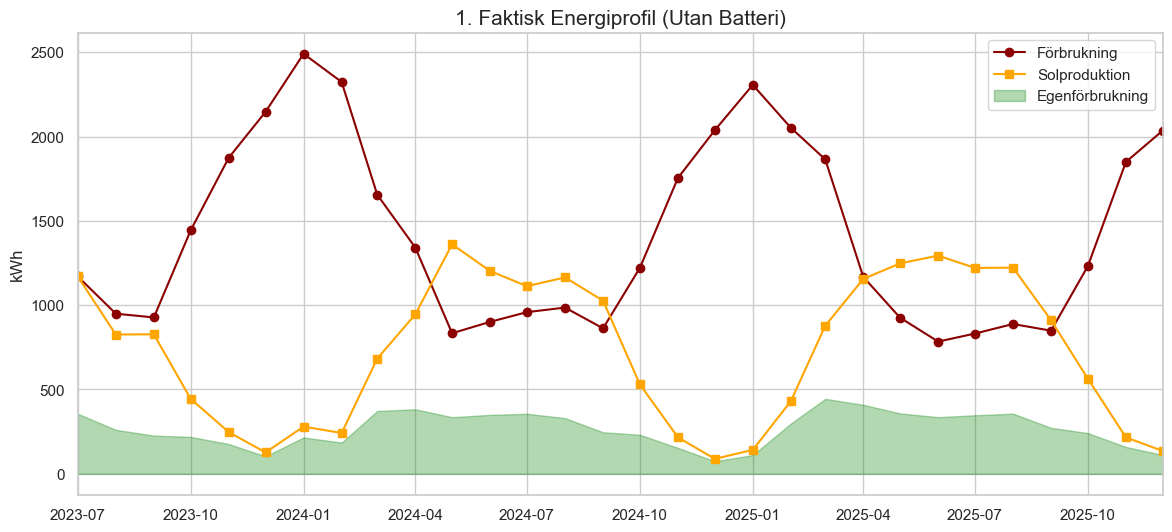

In [17]:
# --- CELL 2: HISTORISK PROFIL ---
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

monthly = df_sim.resample('MS').sum()

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
plt.plot(monthly.index, monthly['total_house_load_kwh'], label='Förbrukning', color='darkred', marker='o')
plt.plot(monthly.index, monthly['total_production_kwh'], label='Solproduktion', color='orange', marker='s')
plt.fill_between(monthly.index, monthly['self_consumption_kwh'], color='green', alpha=0.3, label='Egenförbrukning')

plt.title('1. Faktisk Energiprofil (Utan Batteri)', fontsize=15)
plt.ylabel('kWh'); plt.xlim(monthly.index.min(), monthly.index.max())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.legend(); plt.show()

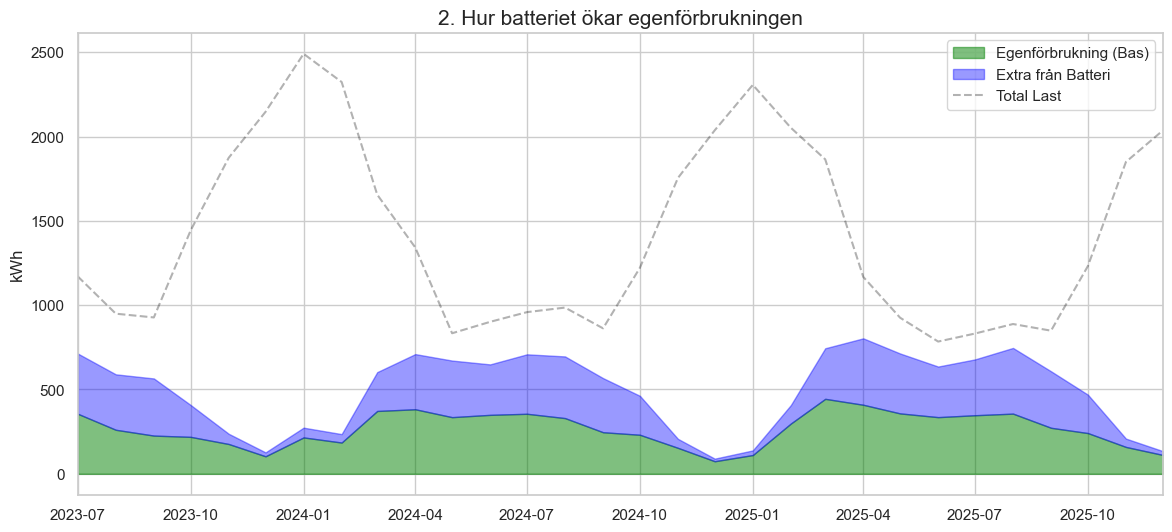

In [18]:
# --- CELL 3: EFFEKT AV BATTERI ---
plt.figure(figsize=(14, 6))
# Gamla egenförbrukningen
plt.fill_between(monthly.index, monthly['self_consumption_kwh'], color='green', alpha=0.5, label='Egenförbrukning (Bas)')
# Ny egenförbrukning (Total last minus det vi fortfarande måste köpa)
new_self = monthly['total_house_load_kwh'] - monthly['new_import']
plt.fill_between(monthly.index, monthly['self_consumption_kwh'], new_self, color='blue', alpha=0.4, label='Extra från Batteri')

plt.plot(monthly.index, monthly['total_house_load_kwh'], color='black', linestyle='--', alpha=0.3, label='Total Last')
plt.title('2. Hur batteriet ökar egenförbrukningen', fontsize=15)
plt.ylabel('kWh'); plt.xlim(monthly.index.min(), monthly.index.max())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.legend(); plt.show()

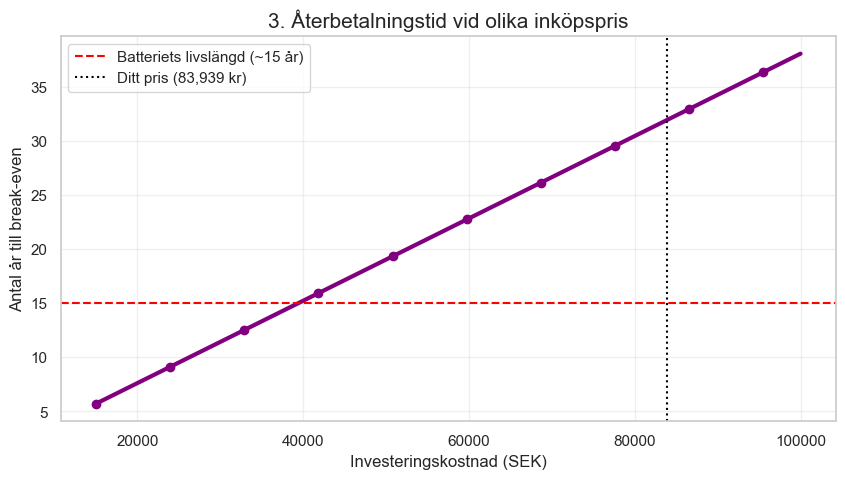

In [19]:
# --- CELL 4: PAYBACK-SENSITIVITET ---
prices = np.linspace(15000, 100000, 20)
paybacks = prices / annual_vinst

plt.figure(figsize=(10, 5))
plt.plot(prices, paybacks, color='purple', linewidth=3, marker='o', markevery=2)
plt.axhline(15, color='red', linestyle='--', label='Batteriets livslängd (~15 år)')
plt.axvline(COST_18KWH, color='black', linestyle=':', label=f'Ditt pris ({COST_18KWH:,.0f} kr)')

plt.title('3. Återbetalningstid vid olika inköpspris', fontsize=15)
plt.xlabel('Investeringskostnad (SEK)'); plt.ylabel('Antal år till break-even')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

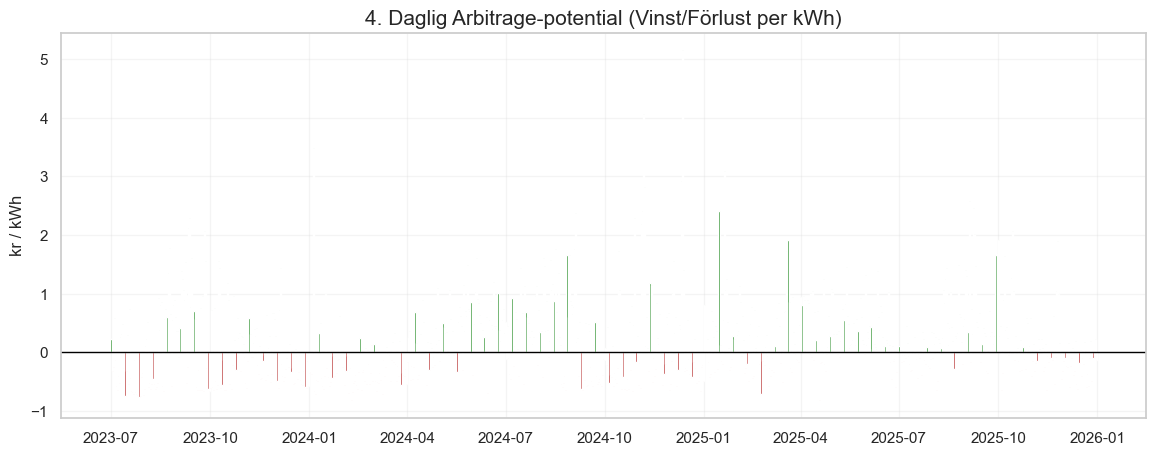

Endast 478 av 915 dagar gav vinst vid ren elhandel.


In [21]:
# --- CELL 5: ARBITRAGE-ANALYS ---
import matplotlib.pyplot as plt

# Beräkna daglig vinst/förlust
# Vi använder timpriserna för att hitta dyraste och billigaste timmen varje dygn
daily = df_sim.groupby(df_sim.index.date)['price_total_ore'].agg(['min', 'max']) / 100

# Här använder vi variabelnamnet EFFICIENCY (som definierats i dina parametrar)
# Logik: (Verkningsgrad * Intäkt vid försäljning) - (Kostnad vid inköp)
daily['arb_profit'] = (EFFICIENCY * (daily['max'] + SELL_ADJUST)) - (daily['min'] * MOMS + TAX_FEES_KR)

plt.figure(figsize=(14, 5))
# Grön stapel för vinst, röd för förlust
colors = ['forestgreen' if x > 0 else 'firebrick' for x in daily['arb_profit']]
plt.bar(daily.index, daily['arb_profit'], color=colors, width=1.0)
plt.axhline(0, color='black', linewidth=1)

plt.title('4. Daglig Arbitrage-potential (Vinst/Förlust per kWh)', fontsize=15)
plt.ylabel('kr / kWh')
plt.grid(True, alpha=0.2)
plt.show()

profitable_days = len(daily[daily['arb_profit'] > 0])
print(f"Endast {profitable_days} av {len(daily)} dagar gav vinst vid ren elhandel.")